## Acknowledgements
Notebook is based on:
Can Yang & Gyozo Gidofalvi (2018) Fast map matching, an algorithm
integrating hidden Markov model with precomputation, International Journal of Geographical Information Science, 32:3, 547-570, DOI: 10.1080/13658816.2017.1400548

In [25]:
import osmnx as ox
import os
import time
from shapely.geometry import Polygon
from shapely.geometry import Point, LineString
import shapely.wkt
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

# Static Vairables

In [26]:
MASK = gpd.read_file("Data/Banks_Mask_Buffered.gpkg").to_crs(epsg=2193)
SALT = 741
FOOT_CYCLE_ONLY = {
    "track",
    "path",
    "cycleway",
    "footway"
}

In [27]:
def save_graph_shapefile_directional(G, filepath=None, encoding="utf-8"):
    os.makedirs(filepath, exist_ok=True)
    filepath_nodes = os.path.join(filepath, "nodes.shp")
    filepath_edges = os.path.join(filepath, "edges.shp")

    # convert undirected graph to gdfs and stringify non-numeric columns
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
    gdf_nodes = ox.io._stringify_nonnumeric_cols(gdf_nodes)
    gdf_edges = ox.io._stringify_nonnumeric_cols(gdf_edges)

    # We need an unique ID for each edge
    gdf_edges["fid"] = np.arange(0, gdf_edges.shape[0], dtype='int')
    # save the nodes and edges as separate ESRI shapefiles
    gdf_nodes.to_file(filepath_nodes, encoding=encoding)
    gdf_edges.to_file(filepath_edges, encoding=encoding)

    return gdf_edges, gdf_nodes

In [52]:
network_filters = {
    "all": None,
    "A": '["highway"~"track|path|cycleway|footway"]',
}

for filter_name, filter_value in network_filters.items():
    graph_kwargs = {
        "network_type": "all",
        "retain_all": True,
    }
    if filter_value is not None:
        graph_kwargs["custom_filter"] = filter_value

    G = ox.graph_from_polygon(
        MASK.to_crs(epsg=4326).geometry[0],
        **graph_kwargs,
    )
    G = ox.project_graph(G, to_crs='epsg:2193')
    gdf_edges, gdf_nodes = save_graph_shapefile_directional(G, filepath=f"Data/Map_Matching/Graph_Filter_{filter_name}")
    gdf_edges = gdf_edges.reset_index()
    gdf_edges = gdf_edges[['u','v','osmid','highway','geometry']]
    gdf_edges.to_file(f"Data/Supplementaries/{filter_name}_Edges.gpkg", driver="GPKG")

C:\Users\maxwe\AppData\Local\Temp\ipykernel_28060\1149002092.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, encoding=encoding)
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
C:\Users\maxwe\AppData\Local\Temp\ipykernel_28060\1149002092.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, encoding=encoding)
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [53]:
a_edges = gpd.read_file("Data/Supplementaries/A_Edges.gpkg")
all_edges = gpd.read_file("Data/Supplementaries/all_Edges.gpkg")

In [41]:
a_edges["osmid"] = a_edges["osmid"].astype(str)
all_edges["osmid"] = all_edges["osmid"].astype(str)

In [72]:
strava_edges = gpd.read_file("Data/Strava/strava_bikeped_osm.gpkg")
strava_edges["osmId"] = strava_edges["osmId"].astype(int)
strava_edges["osmId"] = strava_edges["osmId"].astype(str)

In [77]:
all_edges

,u,v,osmid,highway,geometry
0,31247097,31247104,26598779,secondary,"LINESTRING (1577171.505 5172216.104, 1577174.1..."
1,31247097,11933143590,26598795,secondary,"LINESTRING (1577171.505 5172216.104, 1577187.2..."
2,31247104,291695667,1311909664,secondary,"LINESTRING (1577172.624 5172193.207, 1577169.8..."
3,11933143590,3681518512,364042580,footway,"LINESTRING (1577199.053 5172208.467, 1577200.5..."
4,11933143590,31247098,26598795,secondary,"LINESTRING (1577199.053 5172208.467, 1577200.9..."
...,...,...,...,...,...
16002,13456939461,13456939460,1467157784,footway,"LINESTRING (1576391.029 5171421.887, 1576372.7..."
16003,13477778989,13477778981,1469621394,footway,"LINESTRING (1596047.996 5148420.357, 1596050.1..."
16004,13477788519,13477788523,1469621395,footway,"LINESTRING (1596065.708 5148374.798, 1596066.6..."
16005,13477788519,13477788523,1469621396,footway,"LINESTRING (1596065.708 5148374.798, 1596068.5..."


In [73]:
strava_edges

,edgeUID,osmId,source,geometry
0,38567784,440289756,ped,"LINESTRING (1552032.633 5144532.095, 1551983.0..."
1,38567820,440289756,ped,"LINESTRING (1560319.955 5146560.284, 1560226.6..."
2,38581111,26769833,ped,"LINESTRING (1566546.473 5158272.527, 1566508.7..."
3,38581172,27029338,ped,"LINESTRING (1565866.516 5158766.981, 1565691.1..."
4,38581250,817757847,ped,"LINESTRING (1566488.095 5160706.584, 1566518.9..."
...,...,...,...,...
23134,35002393,682077485,bike,"LINESTRING (1583975.695 5173595.243, 1583980.0..."
23135,35002425,103615691,bike,"LINESTRING (1583890.355 5174297.074, 1583889.5..."
23136,35002427,401702917,bike,"LINESTRING (1583977.586 5174388.33, 1583977.61..."
23137,35002429,1054540983,bike,"LINESTRING (1584174.145 5173335.689, 1584188.1..."


In [76]:
len(all_edges['osmid'].unique())
len(strava_edges['osmId'].unique())

6445

In [75]:
all_ids = set(all_edges["osmid"].dropna())
strava_ids = set(strava_edges["osmId"].dropna())

shared =  all_ids & strava_ids
unique_to_all = all_ids - strava_ids
unique_to_strava = strava_ids - all_ids


print(f"Total distinct ids across datasets: {len(all_ids | strava_ids)}")
print(f"Shared by datasets: {len(shared)}")
print(f"Unique to all_Edges: {len(unique_to_all)}")
print(f"Unique to Strava: {len(unique_to_strava)}")


Total distinct ids across datasets: 7844
Shared by datasets: 3267
Unique to all_Edges: 1399
Unique to Strava: 3178


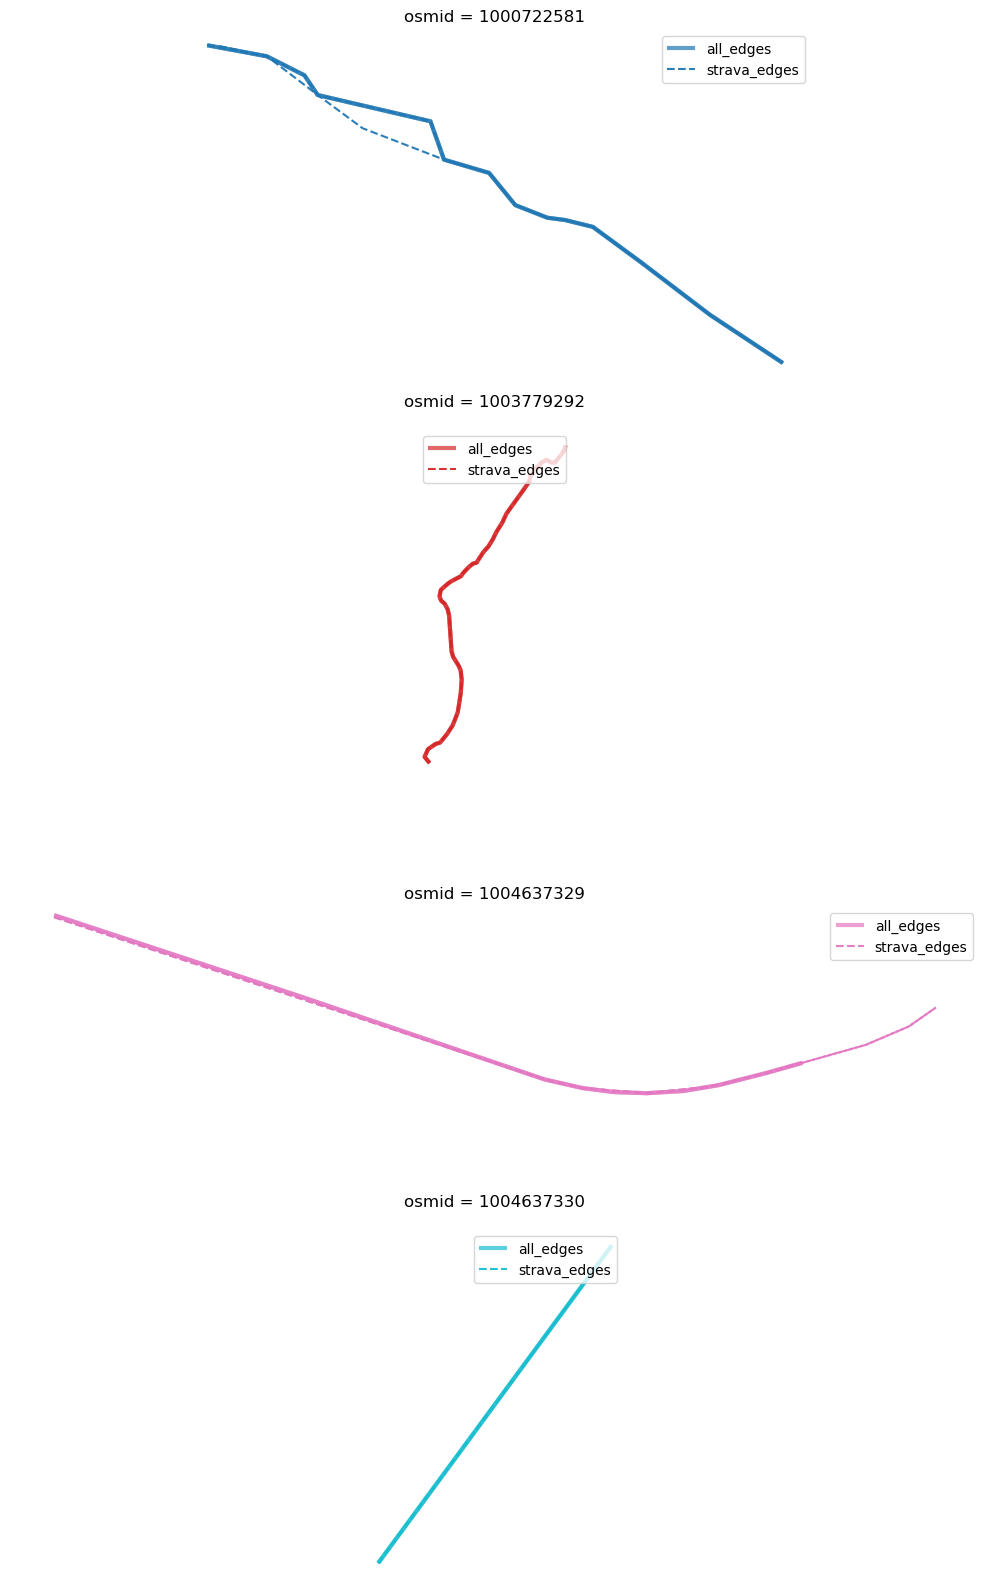

In [79]:
shared_ids = sorted(set(all_edges["osmid"]).intersection(set(strava_edges["osmId"])))
example_ids = shared_ids[:4]

if not example_ids:
    print("No shared osmid values found between all_edges and strava_edges.")
else:
    fig, axes = plt.subplots(len(example_ids), 1, figsize=(10, 4 * len(example_ids)))
    if len(example_ids) == 1:
        axes = [axes]

    color_map = plt.get_cmap("tab10", len(example_ids))

    for ax, osm_id, color in zip(axes, example_ids, color_map.colors):
        all_match = all_edges[all_edges["osmid"] == osm_id].to_crs(epsg=2193)
        strava_match = strava_edges[strava_edges["osmId"] == osm_id].to_crs(epsg=2193)

        all_match.plot(ax=ax, color=color, linewidth=3, alpha=0.7, label="all_edges")
        strava_match.plot(ax=ax, color=color, linewidth=1.5, linestyle="--", alpha=0.95, label="strava_edges")
        ax.set_title(f"osmid = {osm_id}")
        ax.set_axis_off()
        ax.legend(loc="upper right")

    plt.tight_layout()